# **Project Title: Predicting divorce**
by Kabir, Rodrigue and Sertac

**Research main objective**

This project aims to develop and validate predictive models of divorce using multidimensional determinants (demographic, socioeconomic, relational, and psychological characteristics), and to identify the key factors that most strongly contribute to marital dissolution. 

Specifically, it seeks at 

-	Training and comparing multiple supervised learning models and deep learning models to predict divorce
-	Identifiy the most important predictors of divorce


**Research questions**

-	Which supervised machine-learning model and deep learning models offers the most reliable and robust prediction of divorce?

-	Which factors contribute most to predicting divorce ?


**Methods**
-	Exploration of the dataset 
-	Preparation of the dataset
-	Training and comparison of supervised learning models and deep learning models
-	Identification of  the most important predictors of divorce


In [1]:
import sys
print(sys.version)
print(sys.executable)

3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:29:09) [MSC v.1943 64 bit (AMD64)]
c:\Users\kabir\miniforge3\envs\DSPy2025\python.exe


In [2]:
#Load libraries that will be used throughout the project (will be continuouysly updated)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor, plot_importance    
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

**Descriptive Statistics**

In [3]:
# Load the dataset
df = pd.read_csv('divorce_df.csv')
df.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,1,6.212046,3,...,0,0,0,5.263555,5,Love,1,0,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1


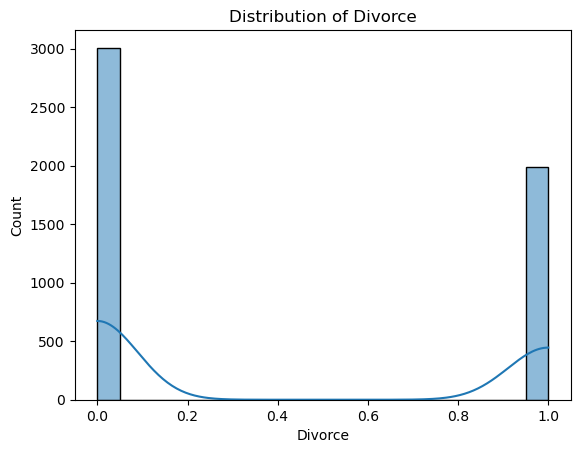

In [4]:
#Distribution of Target Variable
sns.histplot(df['divorced'], bins=20, kde=True)
plt.title('Distribution of Divorce')
plt.xlabel('Divorce')
plt.ylabel('Count')
plt.show()

In [5]:
# Make a copy of the original dataset
df1 = df.copy()
df1.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,1,6.212046,3,...,0,0,0,5.263555,5,Love,1,0,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1


In [6]:
#Show the list of columns in the dataset
df1.columns

Index(['age_at_marriage', 'marriage_duration_years', 'num_children',
       'education_level', 'employment_status', 'combined_income',
       'religious_compatibility', 'cultural_background_match',
       'communication_score', 'conflict_frequency',
       'conflict_resolution_style', 'financial_stress_level',
       'mental_health_issues', 'infidelity_occurred', 'counseling_attended',
       'social_support', 'shared_hobbies_count', 'marriage_type',
       'pre_marital_cohabitation', 'domestic_violence_history', 'trust_score',
       'divorced'],
      dtype='object')

In [7]:
#Extract the dataset to be used for the project
df3 = df1.copy()
df3 = df1[['communication_score', 'financial_stress_level', 'mental_health_issues', 'infidelity_occurred', 'social_support', 'domestic_violence_history', 'trust_score', 'divorced']]
df3.head()

,communication_score,financial_stress_level,mental_health_issues,infidelity_occurred,social_support,domestic_violence_history,trust_score,divorced
0,5.536016,6.026355,0,0,8.428183,0,6.262411,1
1,5.810172,1.000000,0,1,5.297221,0,6.769384,1
2,6.088146,3.199275,0,0,5.887066,0,5.532866,1
3,6.212046,4.893633,0,0,5.263555,0,3.491264,0
4,4.826262,9.431154,0,0,5.771259,0,10.000000,1


In [8]:
# Produce summary statistics of the dataset
df3.describe()

,communication_score,financial_stress_level,mental_health_issues,infidelity_occurred,social_support,domestic_violence_history,trust_score,divorced
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.040507,5.071450,0.203800,0.149000,5.966853,0.050400,6.030525,0.398200
std,1.963349,2.326322,0.402862,0.356124,1.965504,0.218791,1.932922,0.489576
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,4.661929,3.365562,0.000000,0.000000,4.597007,0.000000,4.702663,0.000000
50%,6.058246,5.062464,0.000000,0.000000,6.010716,0.000000,6.034343,0.000000
75%,7.426862,6.717954,0.000000,0.000000,7.328916,0.000000,7.372830,1.000000
max,10.000000,10.000000,1.000000,1.000000,10.000000,1.000000,10.000000,1.000000


In [9]:
# Generating frequency tables for binary variables
binary_columns = ['infidelity_occurred', 'domestic_violence_history', 'divorced', "mental_health_issues"]
for col in binary_columns:
    print(f"Frequency table for {col}:")
    print(df3[col].value_counts())
    print("\n")

Frequency table for infidelity_occurred:
infidelity_occurred
0    4255
1     745
Name: count, dtype: int64


Frequency table for domestic_violence_history:
domestic_violence_history
0    4748
1     252
Name: count, dtype: int64


Frequency table for divorced:
divorced
0    3009
1    1991
Name: count, dtype: int64


Frequency table for mental_health_issues:
mental_health_issues
0    3981
1    1019
Name: count, dtype: int64




In [10]:
# Check for missing values
df3.isnull().sum()

communication_score          0
financial_stress_level       0
mental_health_issues         0
infidelity_occurred          0
social_support               0
domestic_violence_history    0
trust_score                  0
divorced                     0
dtype: int64

**Machine Learning**

In [ ]:
# Make train-test split
# Define feature matrix X and target variable y
X = df3[['communication_score', 'financial_stress_level', 'mental_health_issues', 'infidelity_occurred', 'social_support', 'domestic_violence_history', 'trust_score']]
y = df3['divorced']

In [12]:
# 2. Perform 80/20 train-test split 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print(f"--- Dataset Split Results ---")
print(f"Total samples: {len(df3)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")
print(f"-----------------------------")

--- Dataset Split Results ---
Total samples: 5000
X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train distribution:
divorced
0    0.604
1    0.396
Name: proportion, dtype: float64
y_test distribution:
divorced
0    0.593
1    0.407
Name: proportion, dtype: float64
-----------------------------


In [13]:
# 3. Create preprocessing pipelines for numerical and categorical features
numerical_features = ["communication_score", "financial_stress_level", "social_support", "trust_score"]
categorical_features = ["mental_health_issues", "infidelity_occurred", "domestic_violence_history"]
numerical_transformer = StandardScaler() # Scale continuous features
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Convert categorical features to numerical

# 4. Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

In [14]:
#Creating a pipeline that combines the preprocessor with a Logistic Regression classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])
# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Training and comparison of supervised models**


--- Training Model (Logistic Regression Classifier) ---
Making predictions for the following 5 couples:
   communication_score  financial_stress_level  mental_health_issues  \
0             5.536016                6.026355                     0   
1             5.810172                1.000000                     0   
2             6.088146                3.199275                     0   
3             6.212046                4.893633                     0   
4             4.826262                9.431154                     0   

   infidelity_occurred  social_support  domestic_violence_history  trust_score  
0                    0        8.428183                          0     6.262411  
1                    1        5.297221                          0     6.769384  
2                    0        5.887066                          0     5.532866  
3                    0        5.263555                          0     3.491264  
4                    0        5.771259                   

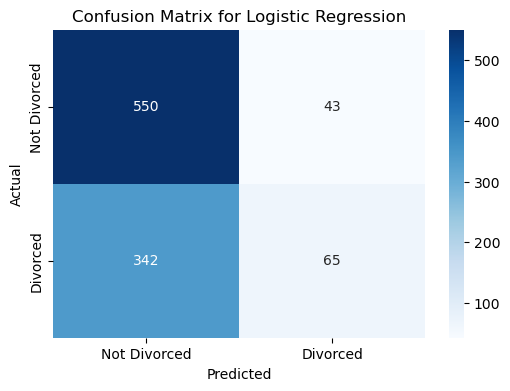

In [15]:
# Predict on the test set
y_pred = pipeline.predict(X_test)

# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Logistic Regression Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(pipeline.predict(X.head()))

print("\n--- Model Evaluation Results---")
print(f"Accuracy on Test Set: {accuracy:.4f}")

print("\n--- Confusion Matrix ---")
print("    Predicted 0 | Predicted 1")
print(f"Actual 0: {conf_matrix[0][0]:>10} | {conf_matrix[0][1]:>10}")
print(f"Actual 1: {conf_matrix[1][0]:>10} | {conf_matrix[1][1]:>10}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization of Confusion Matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Divorced', 'Divorced'],
            yticklabels=['Not Divorced', 'Divorced'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Training Model (Random Forest Classifier) ---
Making predictions for the following 5 couples:
   communication_score  financial_stress_level  mental_health_issues  \
0             5.536016                6.026355                     0   
1             5.810172                1.000000                     0   
2             6.088146                3.199275                     0   
3             6.212046                4.893633                     0   
4             4.826262                9.431154                     0   

   infidelity_occurred  social_support  domestic_violence_history  trust_score  
0                    0        8.428183                          0     6.262411  
1                    1        5.297221                          0     6.769384  
2                    0        5.887066                          0     5.532866  
3                    0        5.263555                          0     3.491264  
4                    0        5.771259                         

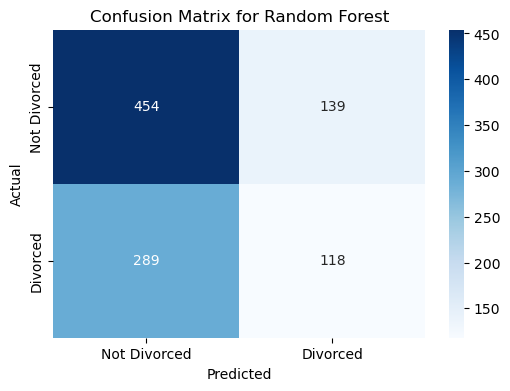

In [16]:
# Define divorce_model1 (Random Forest Classifier)
divorce_model1 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestClassifier(random_state=1))])

# Train the model
divorce_model1.fit(X_train, y_train) 

# Predict on the test set
y_pred = divorce_model1.predict(X_test) 

# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Random Forest Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model1.predict(X.head()))

print("\n--- Model Evaluation Results---")
print(f"Accuracy on Test Set: {accuracy:.4f}")

print("\n--- Confusion Matrix ---")
print("    Predicted 0 | Predicted 1")
print(f"Actual 0: {conf_matrix[0][0]:>10} | {conf_matrix[0][1]:>10}")
print(f"Actual 1: {conf_matrix[1][0]:>10} | {conf_matrix[1][1]:>10}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization of Confusion Matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Divorced', 'Divorced'],
            yticklabels=['Not Divorced', 'Divorced'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



--- Training Model (XGBoost Classifier) ---
Making predictions for the following 5 couples:
   communication_score  financial_stress_level  mental_health_issues  \
0             5.536016                6.026355                     0   
1             5.810172                1.000000                     0   
2             6.088146                3.199275                     0   
3             6.212046                4.893633                     0   
4             4.826262                9.431154                     0   

   infidelity_occurred  social_support  domestic_violence_history  trust_score  
0                    0        8.428183                          0     6.262411  
1                    1        5.297221                          0     6.769384  
2                    0        5.887066                          0     5.532866  
3                    0        5.263555                          0     3.491264  
4                    0        5.771259                          0    

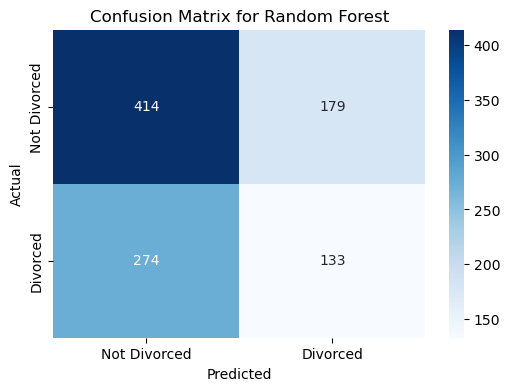

In [17]:
# Define divorce_model1 (Xgboost Classifier)
divorce_model1 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', XGBClassifier(random_state=1))])
# Train the model
divorce_model1.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model1.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (XGBoost Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model1.predict(X.head()))

print("\n--- Model Evaluation Results---")
print(f"Accuracy on Test Set: {accuracy:.4f}")

print("\n--- Confusion Matrix ---")
print("    Predicted 0 | Predicted 1")
print(f"Actual 0: {conf_matrix[0][0]:>10} | {conf_matrix[0][1]:>10}")
print(f"Actual 1: {conf_matrix[1][0]:>10} | {conf_matrix[1][1]:>10}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization of Confusion Matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Divorced', 'Divorced'],
            yticklabels=['Not Divorced', 'Divorced'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Feature Importance**

C:\Users\kabir\AppData\Local\Temp\ipykernel_11212\3068113035.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


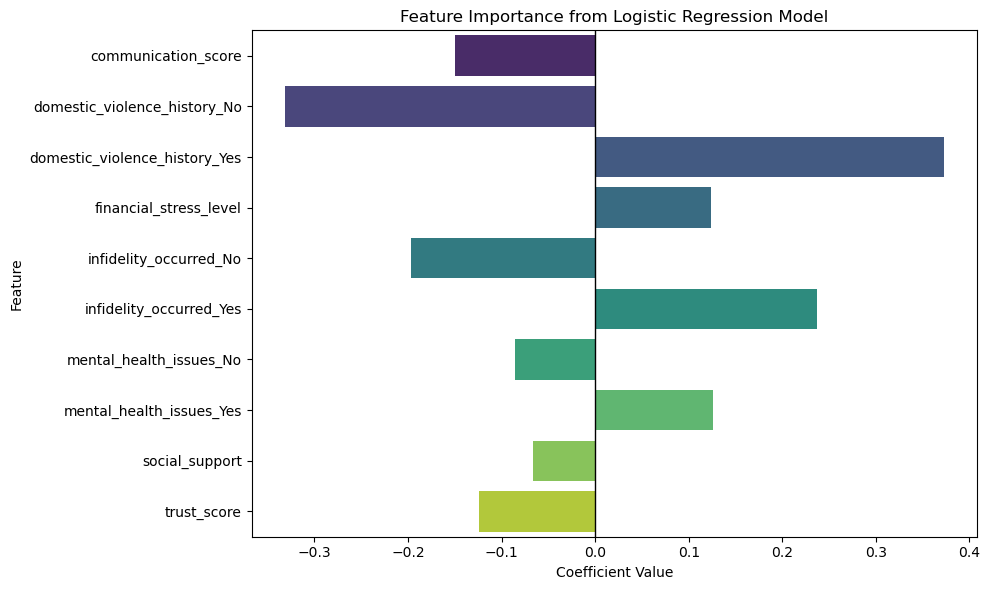

In [18]:
# Extract feature names
feature_names = numerical_features + list(
    pipeline.named_steps['preprocessor']
    .transformers_[1][1]
    .get_feature_names_out(categorical_features)
)

# Convert 0/1 to No/Yes
clean_features = []
for f in feature_names:
    f = f.replace("_0", "_No")
    f = f.replace("_1", "_Yes")
    clean_features.append(f)

# Extract coefficients
coefficients = pipeline.named_steps['classifier'].coef_[0]

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": clean_features,
    "Coefficient": coefficients
})

# Sort alphabetically (this gives the No/Yes pairing)
feature_importance_df = feature_importance_df.sort_values(by="Feature")

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=feature_importance_df,
    palette="viridis"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Feature Importance from Logistic Regression Model")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

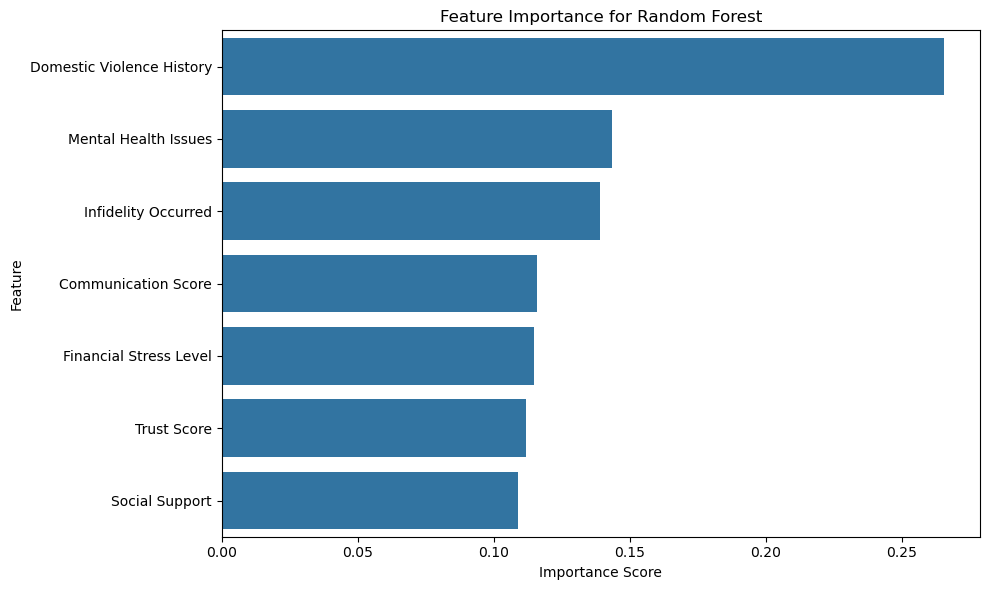

In [19]:
# Get the trained Random Forest model from pipeline
rf_model = divorce_model1.named_steps['classifier']

# Get feature importances
feature_importance = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Remove '_0' and '_1' suffixes (from one-hot encoding)
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace(r'_[01]$', '', regex=True)

# Remove zero importance features (optional but recommended)
feature_importance_df = feature_importance_df[feature_importance_df['Importance'] > 0]

# Sort and keep top 7
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
).head(7)

# Optional: make labels prettier
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('_', ' ').str.title()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title('Feature Importance for Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

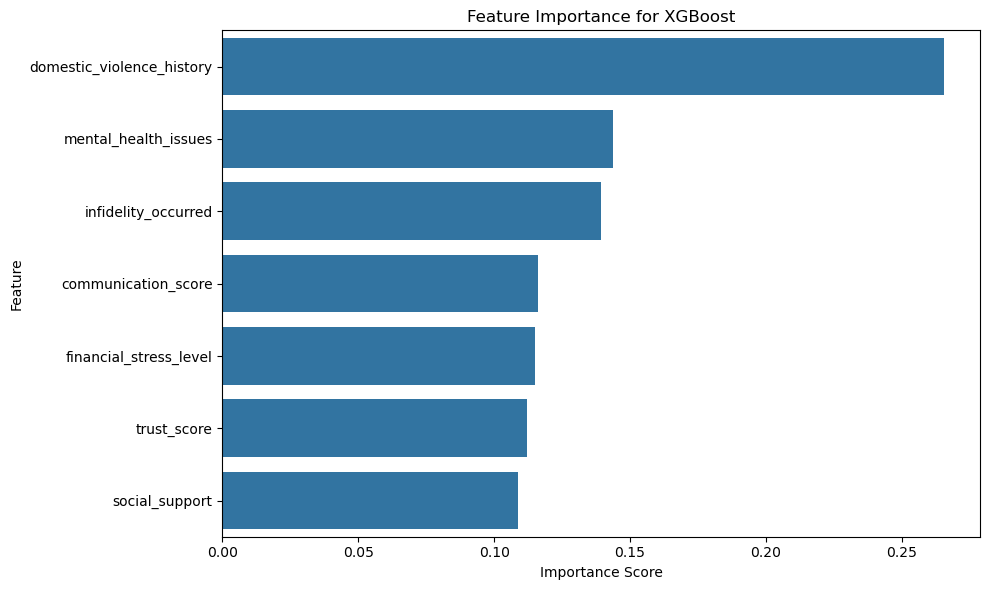

In [20]:
# Get the trained XGBoost model from pipeline
xgb_model = divorce_model1.named_steps['classifier']

# Get feature importances
feature_importance = xgb_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Remove '_0' and '_1' suffixes (recommended for one-hot encoded features)
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace(r'_[01]$', '', regex=True)

# Remove zero-importance features (optional but cleaner)
feature_importance_df = feature_importance_df[feature_importance_df['Importance'] > 0]

# Sort and select top 7
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
).head(7)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title('Feature Importance for XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Deep Learning**

In [21]:
#Create a copy of the dataset and select only the relevant columns for modeling
df1 = df.copy
df1 = df[['communication_score', 'financial_stress_level', 'mental_health_issues', 'infidelity_occurred', 'social_support', 'domestic_violence_history', 'trust_score', 'divorced']]

X = df1.drop('divorced', axis=1)
y = df1['divorced']

In [22]:
#Neural Network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [23]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [24]:
#Converting PyTorch to Tensor
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train.values).unsqueeze(1)
y_test = torch.FloatTensor(y_test.values).unsqueeze(1)

In [25]:
# Deep Feed Forward Neural Network
class DivorceModel(nn.Module):
    def __init__(self, input_dim):
        super(DivorceModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 32)
        self.layer2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()
        self.ReLU = nn.ReLU()

    def forward(self, x):
        x = self.ReLU(self.layer1(x))
        x = self.ReLU(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x
model = DivorceModel(X_train.shape[1])

In [26]:
#Loss & Optimizer

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [27]:
#Train the model

epochs = 100

for epoch in range(epochs):
    #Forward pass
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    #Backwardpass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if(epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6956
Epoch [20/100], Loss: 0.6861
Epoch [30/100], Loss: 0.6785
Epoch [40/100], Loss: 0.6722
Epoch [50/100], Loss: 0.6670
Epoch [60/100], Loss: 0.6629
Epoch [70/100], Loss: 0.6598
Epoch [80/100], Loss: 0.6578
Epoch [90/100], Loss: 0.6566
Epoch [100/100], Loss: 0.6558


In [28]:
#Test Accuracy
with torch.no_grad():
    y_pred_test= model(X_test)
    y_pred_label = (y_pred_test > 0.5).float()

    accuracy = (y_pred_label.numpy() == y_test).sum() / y_test.shape[0]
    print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.6039999723434448


<Figure size 600x400 with 0 Axes>

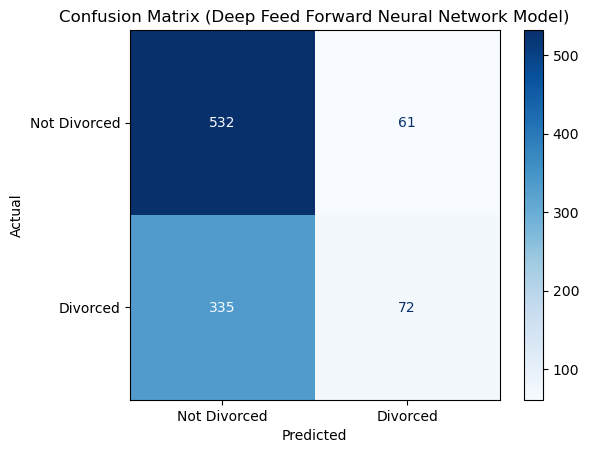

Accuracy: 0.6040
Precision: 0.5414
Recall: 0.1769
F1 Score: 0.2667


In [29]:
cm = confusion_matrix(y_test.numpy(), y_pred_label.numpy())

# Display the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Divorced", "Divorced"])
plt.figure(figsize=(6, 4))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Deep Feed Forward Neural Network Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(y_test.numpy(), y_pred_label.numpy())
precision = precision_score(y_test.numpy(), y_pred_label.numpy())
recall = recall_score(y_test.numpy(), y_pred_label.numpy())
f1 = f1_score(y_test.numpy(), y_pred_label.numpy())
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

ROC-AUC Curve (Model Performance)

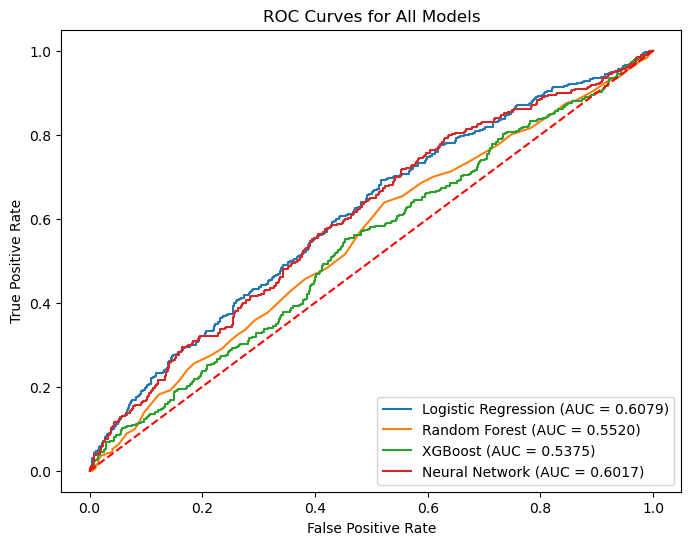

                 Model   ROC-AUC  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.607903     0.615   0.601852  0.159705  0.252427
1        Random Forest  0.551964     0.572   0.459144  0.289926  0.355422
2              XGBoost  0.537487     0.547   0.426282  0.326781  0.369958
3       Neural Network  0.601738     0.604   0.541353  0.176904  0.266667


In [30]:
# praparing data for model comparison
X_train_df = pd.DataFrame(X_train.numpy(), columns=X.columns)
X_test_df = pd.DataFrame(X_test.numpy(), columns=X.columns)

y_train_np = y_train.numpy().ravel()  # Flatten the array to 1D
y_test_np = y_test.numpy().ravel()  # Flatten the array to 1D

# Models to be compared: Logistic Regression, Random Forest, XGBoost, Deep Learning (Neural Network)
logreg_model = pipeline # Logistic Regression model (already defined as 'pipeline')

rf_model = Pipeline([('preprocessor', preprocessor),
                     ('classifier', RandomForestClassifier(random_state=1))])
rf_model.fit(X_train_df, y_train_np)

xgb_model = Pipeline([('preprocessor', preprocessor),
                      ('classifier', XGBClassifier(random_state=1, eval_metric='logloss'))])
xgb_model.fit(X_train_df, y_train_np)

dl_model = model  # Deep Learning model (Neural Network)
 
models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Neural Network": dl_model
}

# Evaluate each model and store results in a table
roc_table = []
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if name == "Neural Network":
        with torch.no_grad():
            y_score = dl_model(X_test).detach().numpy().ravel()
            y_pred_label = (y_score > 0.5).astype(int)
    else:
       # X_test_df = pd.DataFrame(X_test.numpy(), columns=X.columns)
        y_score = model.predict_proba(X_test_df)[:,1]  # Get probabilities for the positive class
        y_pred_label = model.predict(X_test_df)
      
   # Calculate metrics
    roc_auc = roc_auc_score(y_test_np, y_score)
    accuracy = accuracy_score(y_test_np, y_pred_label)
    precision = precision_score(y_test_np, y_pred_label)
    recall = recall_score(y_test_np, y_pred_label)
    f1 = f1_score(y_test_np, y_pred_label)
    
    roc_table.append({
        "Model": name,
        "ROC-AUC": roc_auc,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })  
# Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test_np, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')   

plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Create a DataFrame for the performance metrics
performance_df = pd.DataFrame(roc_table)
print(performance_df)



**Deep Learning Feature Importance**

In [38]:
# Suppose X and y are your full dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

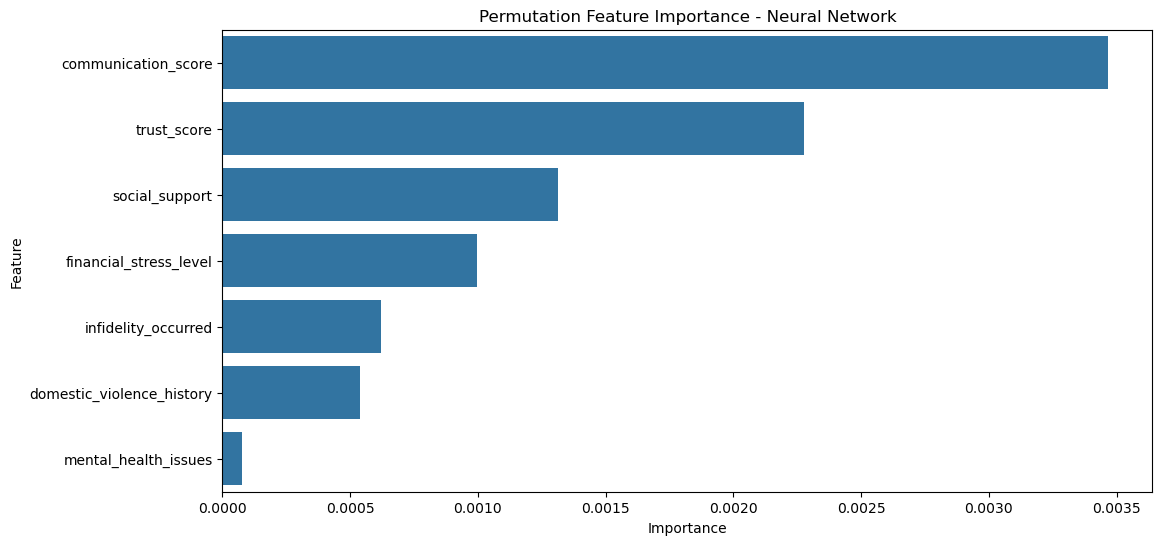

In [41]:
# Convert validation data to tensors
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

# Baseline prediction on validation set
baseline_preds = dl_model(X_val_tensor).detach().numpy()
baseline_score = mean_squared_error(y_val, baseline_preds)

# Permutation importance
importances = []
for i, col in enumerate(X.columns):
    X_shuffled = X_val.copy()
    X_shuffled[col] = np.random.permutation(X_shuffled[col])
    shuffled_tensor = torch.tensor(X_shuffled.values, dtype=torch.float32)
    preds = dl_model(shuffled_tensor).detach().numpy()
    score = mean_squared_error(y_val, preds)
    importances.append(score - baseline_score)  # bigger difference = more important

# Create DataFrame for plotting
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

#Plotting the feature importance
plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Permutation Feature Importance - Neural Network')
plt.show()